# Experiment 1.1 — Multiple Hidden Confounders, Variance-Locked (num_A = 3)

**Goal:** Test whether the LOO bound's failure point shifts when the hidden confounding is
split across multiple variables, holding total confounding power constant.

**The variance trap (why normalization matters):**
With `num_A=3` and `beta_da=0.5m`, each confounder contributes variance $(0.5m)^2$, so the
total hidden variance becomes $3 \times (0.5m)^2$ — three times larger than in Experiment 1.
That would conflate dimensionality with raw confounder strength.

To isolate the dimensionality effect, we **lock total variance** by normalizing:
$$\beta_{DA} = \frac{0.5m}{\sqrt{\text{num\_A}}}$$

With this normalization, the three confounders jointly contribute exactly $(0.5m)^2$ of
variance — identical to the single-confounder baseline.

**Setup** — identical to Experiment 1 except `num_A = 3`, variance-locked:
- $D^* = X\beta_{DX} + A\beta_{DA} + \varepsilon_D$, $\quad D = \mathbf{1}[D^* > 0]$
- $Y = \tau D + X\beta_{YX} + A\beta_{YA} + \varepsilon_Y$
- $\tau_{\text{true}} = 1.0$
- $\beta_{DX} = \beta_{YX} = [0.5, 0.5, 0.5, 0.5, 0.5]$ — all covariates equal strength
- $A \in \mathbb{R}^{n \times 3}$, columns i.i.d. $\mathcal{N}(0, I)$, independent of $X$
- $\beta_{DA} = \beta_{YA} = \frac{0.5m}{\sqrt{3}}$ per column — total variance $(0.5m)^2$
- Multiplier $m$ sweeps from $0.5$ to $2.0$ (50 steps)

**Key prediction:** If the LOO bound cares only about total variance explained, the cliff
should land at essentially the same $m$ as Experiment 1 (single confounder).

In [1]:
import sys
import os
sys.path.insert(0, os.path.join('..', 'src'))

import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from dgp import DGPConfig, generate_data
from loo_benchmark import loo_benchmark

plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})
import importlib
import ovb_formula as _ovb_mod
importlib.reload(_ovb_mod)
from ovb_formula import compute_RV
from robustness_plot import plot_robustness_contour

In [ ]:
tau_true   = 1.0
n_trials   = 250
num_A      = 3

beta_dx    = 0.5
beta_yx    = 0.5

multipliers = np.linspace(0.5, 2.0, 50)

coverage        = []
mean_ovb        = []
mean_Bmax       = []
mean_RV         = []
mean_rho        = []
mean_signed_rho = []
p10_rho         = []
p90_rho         = []
p10_signed_rho  = []
p90_signed_rho  = []
mean_sig_slack  = []
mean_r2_ax      = []
last_trial_data = {}

for m_idx, multiplier in enumerate(multipliers):
    # Variance-locked: total hidden variance = (0.5m)^2, identical to Exp 1
    beta_da = (0.5 * multiplier) / np.sqrt(num_A)
    beta_ya = (0.5 * multiplier) / np.sqrt(num_A)

    covered         = 0
    ovb_vals        = []
    B_vals          = []
    rv_vals         = []
    rho_vals        = []
    signed_rho_vals = []
    sig_slack_vals  = []
    r2_ax_vals      = []

    for trial in range(n_trials):
        seed = m_idx * n_trials + trial

        config = DGPConfig(
            num_X=5, num_A=num_A,
            beta_dx=beta_dx, beta_da=beta_da,
            beta_yx=beta_yx, beta_ya=beta_ya,
            seed=seed,
        )
        Y, D, X, A = generate_data(config)

        short_fit = sm.OLS(Y, sm.add_constant(np.column_stack([D, X]))).fit()
        tau_short = short_fit.params[1]
        se_short  = short_fit.bse[1]

        loo_results, S2_full = loo_benchmark(Y, D, X)
        B_max = max(r['B'] for r in loo_results)
        RV    = compute_RV(tau_short, S2_full)

        ovb = abs(tau_short - tau_true)
        ovb_vals.append(ovb)
        B_vals.append(B_max)
        rv_vals.append(RV)

        rho_vals.append(ovb / B_max if B_max > 0 else np.nan)

        signed_ovb = tau_short - tau_true
        signed_rho_vals.append(signed_ovb / B_max if B_max > 0 else np.nan)

        lower_ci = abs(tau_short) - 1.96 * se_short
        sig_slack_vals.append(lower_ci / B_max if B_max > 0 else np.nan)

        # R²(A₁ ~ X) for the first confounder column; representative for all three
        r2_ax_vals.append(sm.OLS(A[:, 0], sm.add_constant(X)).fit().rsquared)

        if ovb <= B_max:
            covered += 1

        last_trial_data[m_idx] = (tau_short, S2_full, loo_results)

    coverage.append(100.0 * covered / n_trials)
    mean_ovb.append(np.mean(ovb_vals))
    mean_Bmax.append(np.mean(B_vals))
    mean_RV.append(np.mean(rv_vals))
    mean_rho.append(np.nanmean(rho_vals))
    mean_signed_rho.append(np.nanmean(signed_rho_vals))
    p10_rho.append(np.nanpercentile(rho_vals, 10))
    p90_rho.append(np.nanpercentile(rho_vals, 90))
    p10_signed_rho.append(np.nanpercentile(signed_rho_vals, 10))
    p90_signed_rho.append(np.nanpercentile(signed_rho_vals, 90))
    mean_sig_slack.append(np.nanmean(sig_slack_vals))
    mean_r2_ax.append(np.nanmean(r2_ax_vals))

    print(f"m={multiplier:5.2f}  coverage={coverage[-1]:5.1f}%  "
          f"mean|OVB|={mean_ovb[-1]:.4f}  mean B_max={mean_Bmax[-1]:.4f}  "
          f"mean RV={mean_RV[-1]:.4f}  mean ρ={mean_rho[-1]:.3f}  "
          f"signed ρ={mean_signed_rho[-1]:.3f}  "
          f"sig_slack={mean_sig_slack[-1]:.3f}  R²(A₁|X)={mean_r2_ax[-1]:.4f}")

In [ ]:
np.save('experiment_01_1_results.npy', {
    'multipliers':      np.array(multipliers),
    'coverage':         np.array(coverage),
    'mean_ovb':         np.array(mean_ovb),
    'mean_Bmax':        np.array(mean_Bmax),
    'mean_RV':          np.array(mean_RV),
    'mean_rho':         np.array(mean_rho),
    'mean_signed_rho':  np.array(mean_signed_rho),
    'p10_rho':          np.array(p10_rho),
    'p90_rho':          np.array(p90_rho),
    'p10_signed_rho':   np.array(p10_signed_rho),
    'p90_signed_rho':   np.array(p90_signed_rho),
    'mean_sig_slack':   np.array(mean_sig_slack),
    'mean_r2_ax':       np.array(mean_r2_ax),
}, allow_pickle=True)
print("Saved → experiment_01_1_results.npy")

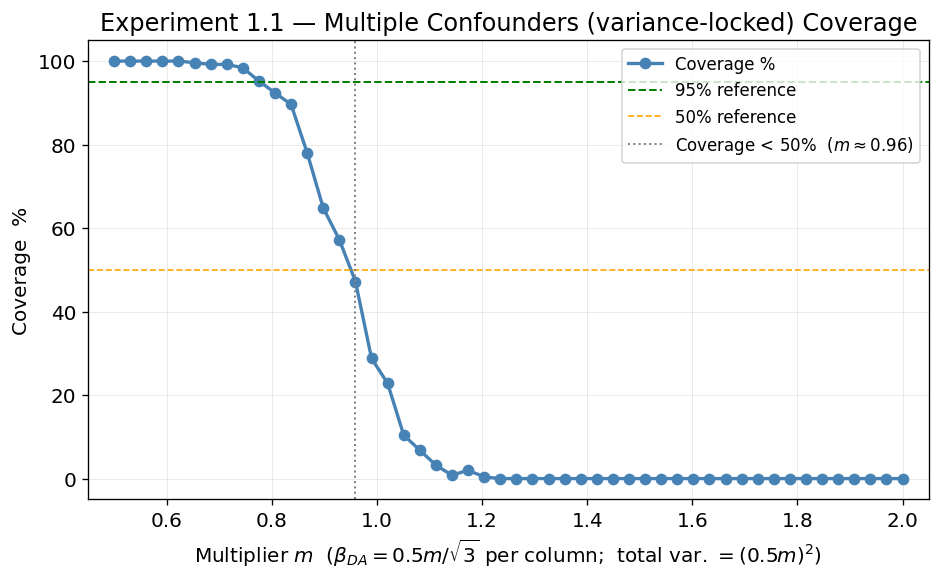

In [3]:
cliff_idx = next((i for i, c in enumerate(coverage) if c < 50), None)
cliff_m   = multipliers[cliff_idx] if cliff_idx is not None else None

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(multipliers, coverage, marker='o', linewidth=2, color='steelblue', label='Coverage %')
ax.axhline(95, linestyle='--', color='green',  linewidth=1.2, label='95% reference')
ax.axhline(50, linestyle='--', color='orange', linewidth=1.0, label='50% reference')
if cliff_m is not None:
    ax.axvline(cliff_m, linestyle=':', color='gray', linewidth=1.2,
               label=f'Coverage < 50%  ($m \\approx {cliff_m:.2f}$)')

ax.set_xlabel(r'Multiplier $m$  ($\beta_{DA} = 0.5m / \sqrt{3}$ per column;  total var. $= (0.5m)^2$)')
ax.set_ylabel('Coverage  %')
ax.set_title('Experiment 1.1 — Multiple Confounders (variance-locked) Coverage')
ax.set_ylim(-5, 105)
ax.set_xlim(multipliers[0] - 0.05, multipliers[-1] + 0.05)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/experiment_01_1_multiple_A_coverage.png', bbox_inches='tight')
plt.show()

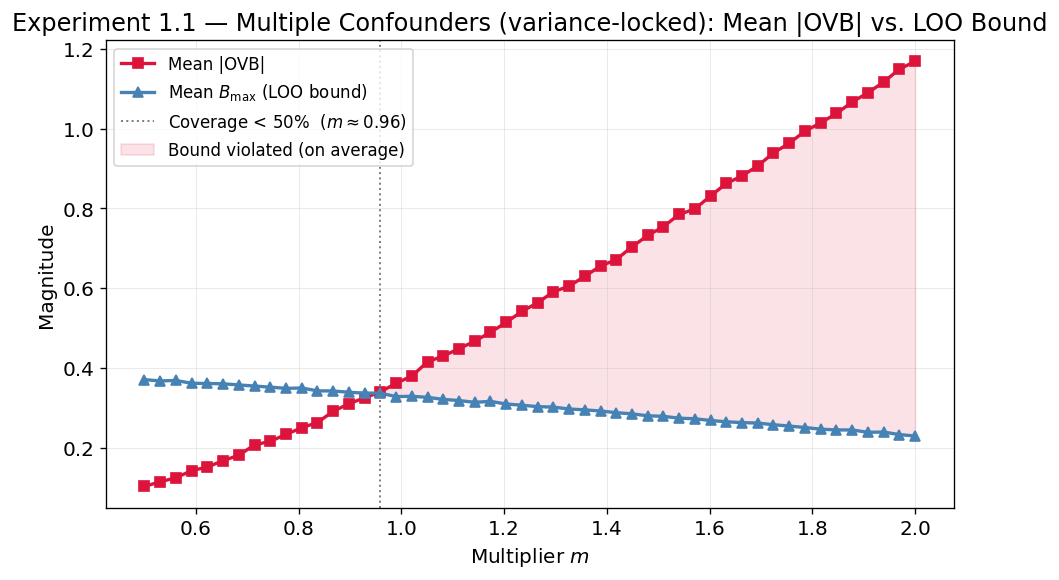

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(multipliers, mean_ovb,  marker='s', linewidth=2, color='crimson',
        label='Mean |OVB|')
ax.plot(multipliers, mean_Bmax, marker='^', linewidth=2, color='steelblue',
        label=r'Mean $B_{\max}$ (LOO bound)')
if cliff_m is not None:
    ax.axvline(cliff_m, linestyle=':', color='gray', linewidth=1.2,
               label=f'Coverage < 50%  ($m \\approx {cliff_m:.2f}$)')

ovb_arr  = np.array(mean_ovb)
bmax_arr = np.array(mean_Bmax)
ax.fill_between(multipliers, ovb_arr, bmax_arr,
                where=(ovb_arr > bmax_arr),
                color='crimson', alpha=0.12, label='Bound violated (on average)')

ax.set_xlabel(r'Multiplier $m$')
ax.set_ylabel('Magnitude')
ax.set_title('Experiment 1.1 — Multiple Confounders (variance-locked): Mean |OVB| vs. LOO Bound')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/experiment_01_1_multiple_A_ovb_vs_bound.png', bbox_inches='tight')
plt.show()

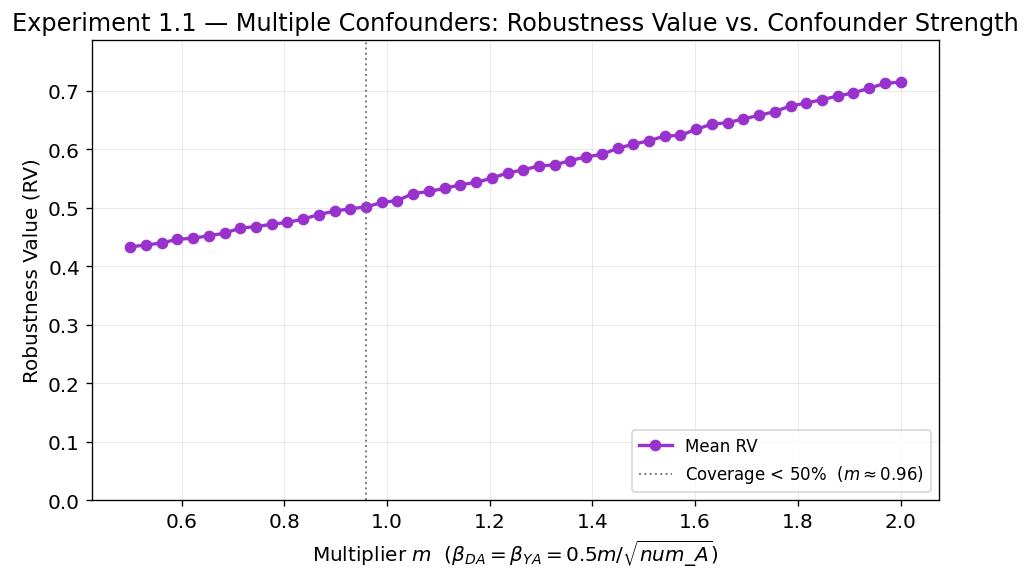

In [5]:
cliff_idx = next((i for i, c in enumerate(coverage) if c < 50), None)
cliff_m   = multipliers[cliff_idx] if cliff_idx is not None else None

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(multipliers, mean_RV, marker='o', linewidth=2, color='darkorchid', label='Mean RV')
if cliff_m is not None:
    ax.axvline(cliff_m, linestyle=':', color='gray', linewidth=1.2,
               label=f'Coverage < 50%  ($m \\approx {cliff_m:.2f}$)')

ax.set_xlabel(r'Multiplier $m$  ($\beta_{DA}=\beta_{YA}=0.5m/\sqrt{{num\_A}}$)')
ax.set_ylabel('Robustness Value (RV)')
ax.set_title('Experiment 1.1 — Multiple Confounders: Robustness Value vs. Confounder Strength')
ax.set_ylim(0, max(mean_RV) * 1.1)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/experiment_01_1_multiple_confounders_rv.png', bbox_inches='tight')
plt.show()

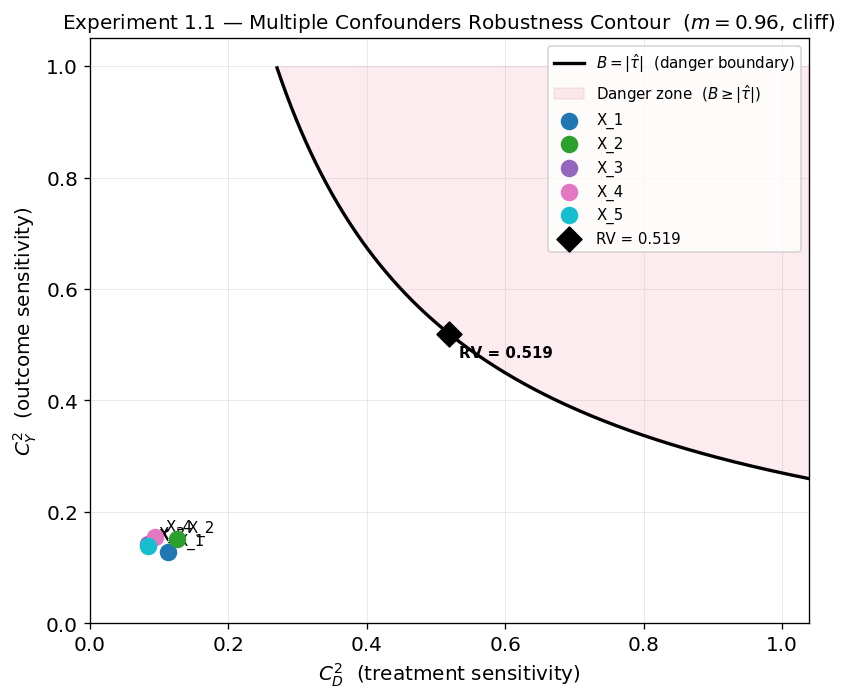

In [6]:
cliff_idx  = next((i for i, c in enumerate(coverage) if c < 50), len(multipliers) - 1)
cliff_m    = multipliers[cliff_idx]
tau_s, S2, loo_r = last_trial_data[cliff_idx]

fig, ax = plt.subplots(figsize=(7, 6))
plot_robustness_contour(
    tau_hat     = tau_s,
    S2          = S2,
    loo_results = loo_r,
    ax          = ax,
    title       = f'Experiment 1.1 — Multiple Confounders Robustness Contour  ($m = {cliff_m:.2f}$, cliff)',
)
plt.tight_layout()
plt.savefig('figures/experiment_01_1_multiple_confounders_contour.png', bbox_inches='tight')
plt.show()

In [7]:
import pandas as pd

df = pd.DataFrame({
    'Multiplier':   multipliers,
    'beta_DA_raw':  0.5 * multipliers,
    'beta_DA_adj':  (0.5 * multipliers) / np.sqrt(num_A),
    'Coverage (%)': coverage,
    'Mean |OVB|':   mean_ovb,
    'Mean B_max':   mean_Bmax,
    'Bound Slack':  np.array(mean_Bmax) - np.array(mean_ovb),
})

df = df.round(4)
df.style.format(precision=4) \
        .background_gradient(subset=['Coverage (%)'], cmap='RdYlGn', vmin=0, vmax=100) \
        .background_gradient(subset=['Bound Slack'],  cmap='RdYlGn', vmin=-1, vmax=1)

,Multiplier,beta_DA_raw,beta_DA_adj,Coverage (%),Mean |OVB|,Mean B_max,Bound Slack
0,0.5000,0.2500,0.1443,100.0000,0.1025,0.3702,0.2677
1,0.5306,0.2653,0.1532,100.0000,0.1142,0.3671,0.2529
2,0.5612,0.2806,0.1620,100.0000,0.1242,0.3682,0.2439
3,0.5918,0.2959,0.1708,100.0000,0.1421,0.3613,0.2191
4,0.6224,0.3112,0.1797,100.0000,0.1512,0.3606,0.2094
5,0.6531,0.3265,0.1885,99.6000,0.1672,0.3599,0.1927
6,0.6837,0.3418,0.1974,99.2000,0.1807,0.3570,0.1763
7,0.7143,0.3571,0.2062,99.2000,0.2068,0.3542,0.1473
8,0.7449,0.3724,0.2150,98.4000,0.2155,0.3514,0.1359
9,0.7755,0.3878,0.2239,95.2000,0.2330,0.3484,0.1154


## Interpretation

**If the cliff lands at the same $m$ as Experiment 1:**
The LOO bound's failure point is driven purely by total confounding variance, not by
the number of hidden variables. Splitting the confounder into 3 equal pieces (with
locked total variance) makes no difference — the bound sees the same aggregate signal.
This would confirm that LOO is sensitive to *how strong* omitted variables are, not
*how many* there are.

**If the cliff shifts:**
Any shift relative to Experiment 1 reveals a genuine dimensionality effect beyond
what variance alone explains — for instance, partial $R^2$ aggregation behaving
differently across multiple small confounders vs. one large one.

**The variance trap (what would happen without normalization):**
Without the $1/\sqrt{\text{num\_A}}$ adjustment, setting `num_A=3` with `beta_da=0.5m`
inflates total hidden variance to $3 \times (0.5m)^2$. The graph would crash far earlier
than Experiment 1 — not because the algorithm handles dimensionality poorly, but because
the experiment inadvertently ran a 3× stronger confounder.

**Implication for practitioners:**
A researcher who worries "what if there are *many* small omitted variables?" can take
some comfort here: if the total confounding is bounded, the LOO bound's failure point
is approximately invariant to how that total is distributed across dimensions.